In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_theme()

In [4]:
simexp_path = Path.cwd().parent / "simulation_result"

In [14]:
df = pd.read_csv(simexp_path / "pareto_fronts_strategy1c.csv")

In [15]:
df.head()

,generation,entry,id,reward,energy_consumption_average,packet_loss_average
0,1,0,Task 48,174.276,9.381892,0.076297
1,1,1,Task 81,174.065,9.251778,0.080045
2,1,2,Task 50,173.825,9.074257,0.081254
3,1,3,Task 156,172.750,9.031676,0.086041
4,1,4,Task 147,174.546,9.272088,0.077567


In [16]:
generations = df["generation"].drop_duplicates()
#print("generations: %s" % generations)
selected_generations = sorted(
    set([generations.iloc[0], generations.iloc[-1]] + list(generations.iloc[::7]))
)
print("selected: %s" % selected_gens)
df_reduced = df[df["generation"].isin(selected_generations)]

selected: [np.int64(1), 8, 15, 22, np.int64(27)]


In [17]:
df_reduced.head()

,generation,entry,id,reward,energy_consumption_average,packet_loss_average
0,1,0,Task 48,174.276,9.381892,0.076297
1,1,1,Task 81,174.065,9.251778,0.080045
2,1,2,Task 50,173.825,9.074257,0.081254
3,1,3,Task 156,172.750,9.031676,0.086041
4,1,4,Task 147,174.546,9.272088,0.077567


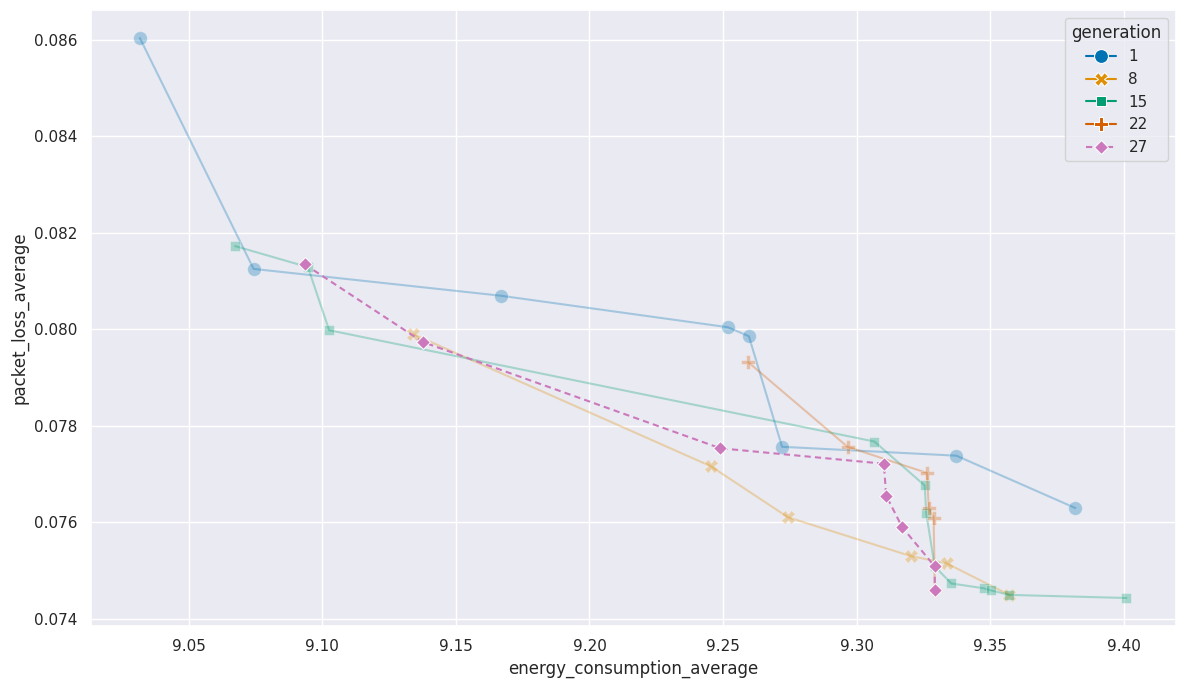

In [32]:
dashes_dict = {gen: () for gen in df_reduced["generation"].unique()}
las_generation = df_reduced.iloc[-1]["generation"]
dashes_dict[las_generation] = (3, 2)  # 3 points line, 2 points space = dashed

plt.figure(figsize=(14, 8))
ax = sns.lineplot(data=df_reduced,
             x="energy_consumption_average", y="packet_loss_average",
             hue="generation", style="generation",
             markers=True,
             markersize=10,
             #dashes=False,
             dashes=dashes_dict,
             legend="full",
             palette="colorblind",
             #alpha=1,
            )
handles, labels = ax.get_legend_handles_labels()
last_label = str(las_generation)
for line, label in zip(ax.lines, labels):
    if label == last_label:
        line.set_alpha(1.0)   # fully opaque
        #line.set_linewidth(3)
    else:
        line.set_alpha(0.3)   # others semi-transparent
plt.show()